In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

### TASK 1

In [2]:

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import pandas as pd
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


In [3]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")


Total images loaded: 60


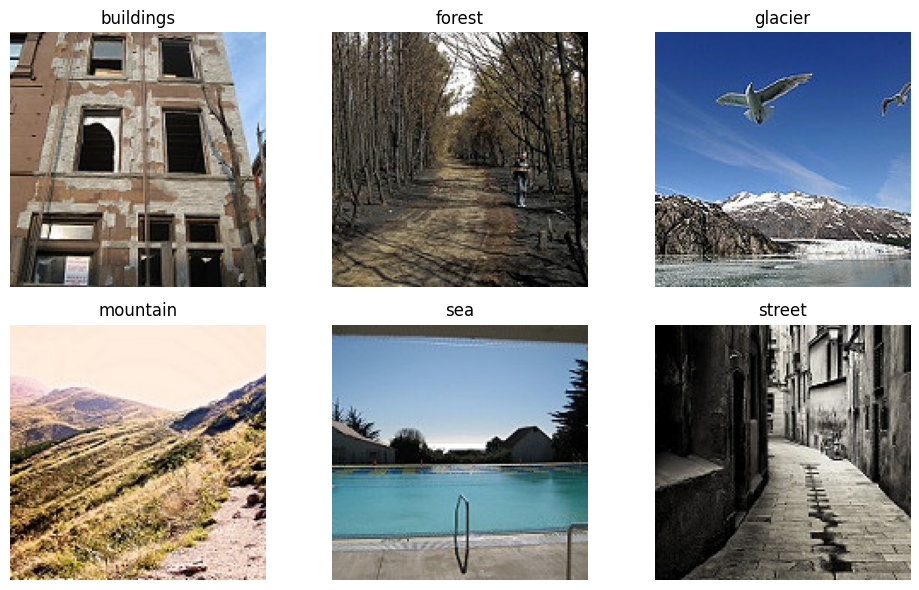

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, label in enumerate(LABELS):
    img = next(img for img, lbl in image_set if lbl ==label)
    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

# It is a reasonable starting point. It is less about the labels and more about the 
# specific characteristics of the images. We could instead choose to train the model
# which is more expensive and time-intensive.

### Task 2: Baseline Inference with ResNet18

In [5]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


ResNet18 parameters: 11,689,512


In [6]:
def run_inference(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))

    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))

    with torch.no_grad():
        output = model(input_tensor)

    
    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
    
    probs = torch.nn.functional.softmax(output[0], dim=0)

    
    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    
    top_probs, top_indices = torch.topk(probs, 5)
    
    # Step 5: Build and return a list of (class_name, probability) tuples
    
    predicted_classes = [(class_labels[idx.item()], prob.item()) for prob, idx in zip(top_probs, top_indices)]
    return predicted_classes

0.41947648823261263 ['bell cote', 'seashore', 'space shuttle', 'valley', 'worm fence', 'volcano', 'worm fence', 'prison', 'passenger car', 'promontory', 'alp', 'seashore', 'viaduct', 'streetcar', 'palace', 'prison', 'cliff', 'palace', 'alp', 'volcano', 'seashore', 'solar dish', 'alp', 'promontory', 'obelisk', 'seashore', 'alp', 'killer whale', 'solar dish', 'prison', 'beacon', 'volcano', 'stone wall', 'jinrikisha', 'palace', 'breakwater', 'worm fence', 'alp', 'seashore', 'radiator', 'restaurant', 'promontory', 'alp', 'viaduct', 'promontory', 'limousine', 'breakwater', 'microphone', 'snowmobile', 'valley', 'killer whale', 'palace', 'palace', 'promontory', 'valley', 'valley', 'valley', 'lakeside', 'gondola', 'alp']


'\nModels can be very confident even when wrong. If an image has a confidence score of over 70%, I would send it for review just to make sure. If the models consistently\n return scores below 20, I would also send those images for human review.\n\n\n'

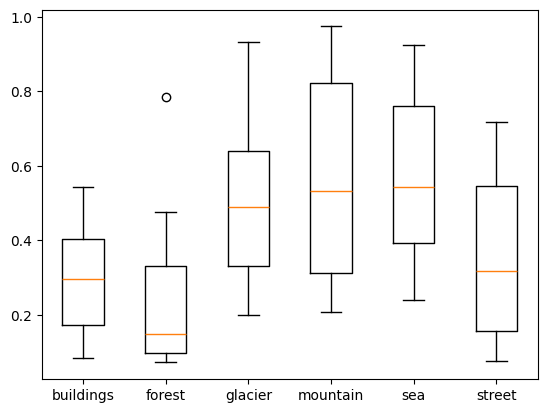

In [ ]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

top1_list = []
top1_classes = []

for result in resnet_results:
    top1_list.append(result["top1_prob"])
    top1_classes.append(result["top1_class"])

mean1 = np.mean(top1_list)
print(f"Overall Mean Top-1 Probability: {mean1}")

print(mean1, top1_classes)

grouped = [[result["top1_prob"] for result in resnet_results if result["true_label"] == label] for label in LABELS]
for label, probs in zip(LABELS, grouped):
    print(f"Class '{label}': {np.mean(probs):.4f}")
plt.boxplot(grouped, tick_labels=LABELS)
plt.savefig("outputs/resnet18_confidence_by_class.png")

#print(f"Processed {len(resnet_results)} images.")



"""
Models can be very confident even when wrong. If an image has a confidence score of over 70%, I would send it for review just to make sure. If the models consistently
 return scores below 20, I would also send those images for human review.


"""

### Task 3: Multi-Model Comparison

In [8]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# The parameter count for the Mobile one implies it is 
#streamlined for efficiency and speed at the cost of performance

# Smaller models usually have performance tradeoffs and better
#for simple tasks compared to the larger models

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 106MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


In [9]:
mobilenet_results = []
effnet_results = []
resnet_results = []
models = [resnet, mobilenet, efficientnet]
model_preproc = [resnet_preproc, mobile_preproc, effnet_preproc]
for model, preproc, results_list in zip(models, model_preproc, [resnet_results, mobilenet_results, effnet_results]):
    model_results = []
    for img, true_label in image_set:
        preds = run_inference(model, preproc , img, device, imagenet_classes)
        model_results.append({
            "true_label":   true_label,
            "top1_class":   preds[0][0],
            "top1_prob":    preds[0][1],
            "top5_classes": [p[0] for p in preds],
            "top5_probs":   [p[1] for p in preds],
        })
    results_list.extend(model_results)
    print(f"Processed {len(results_list)} images.")


Processed 60 images.
Processed 60 images.
Processed 60 images.


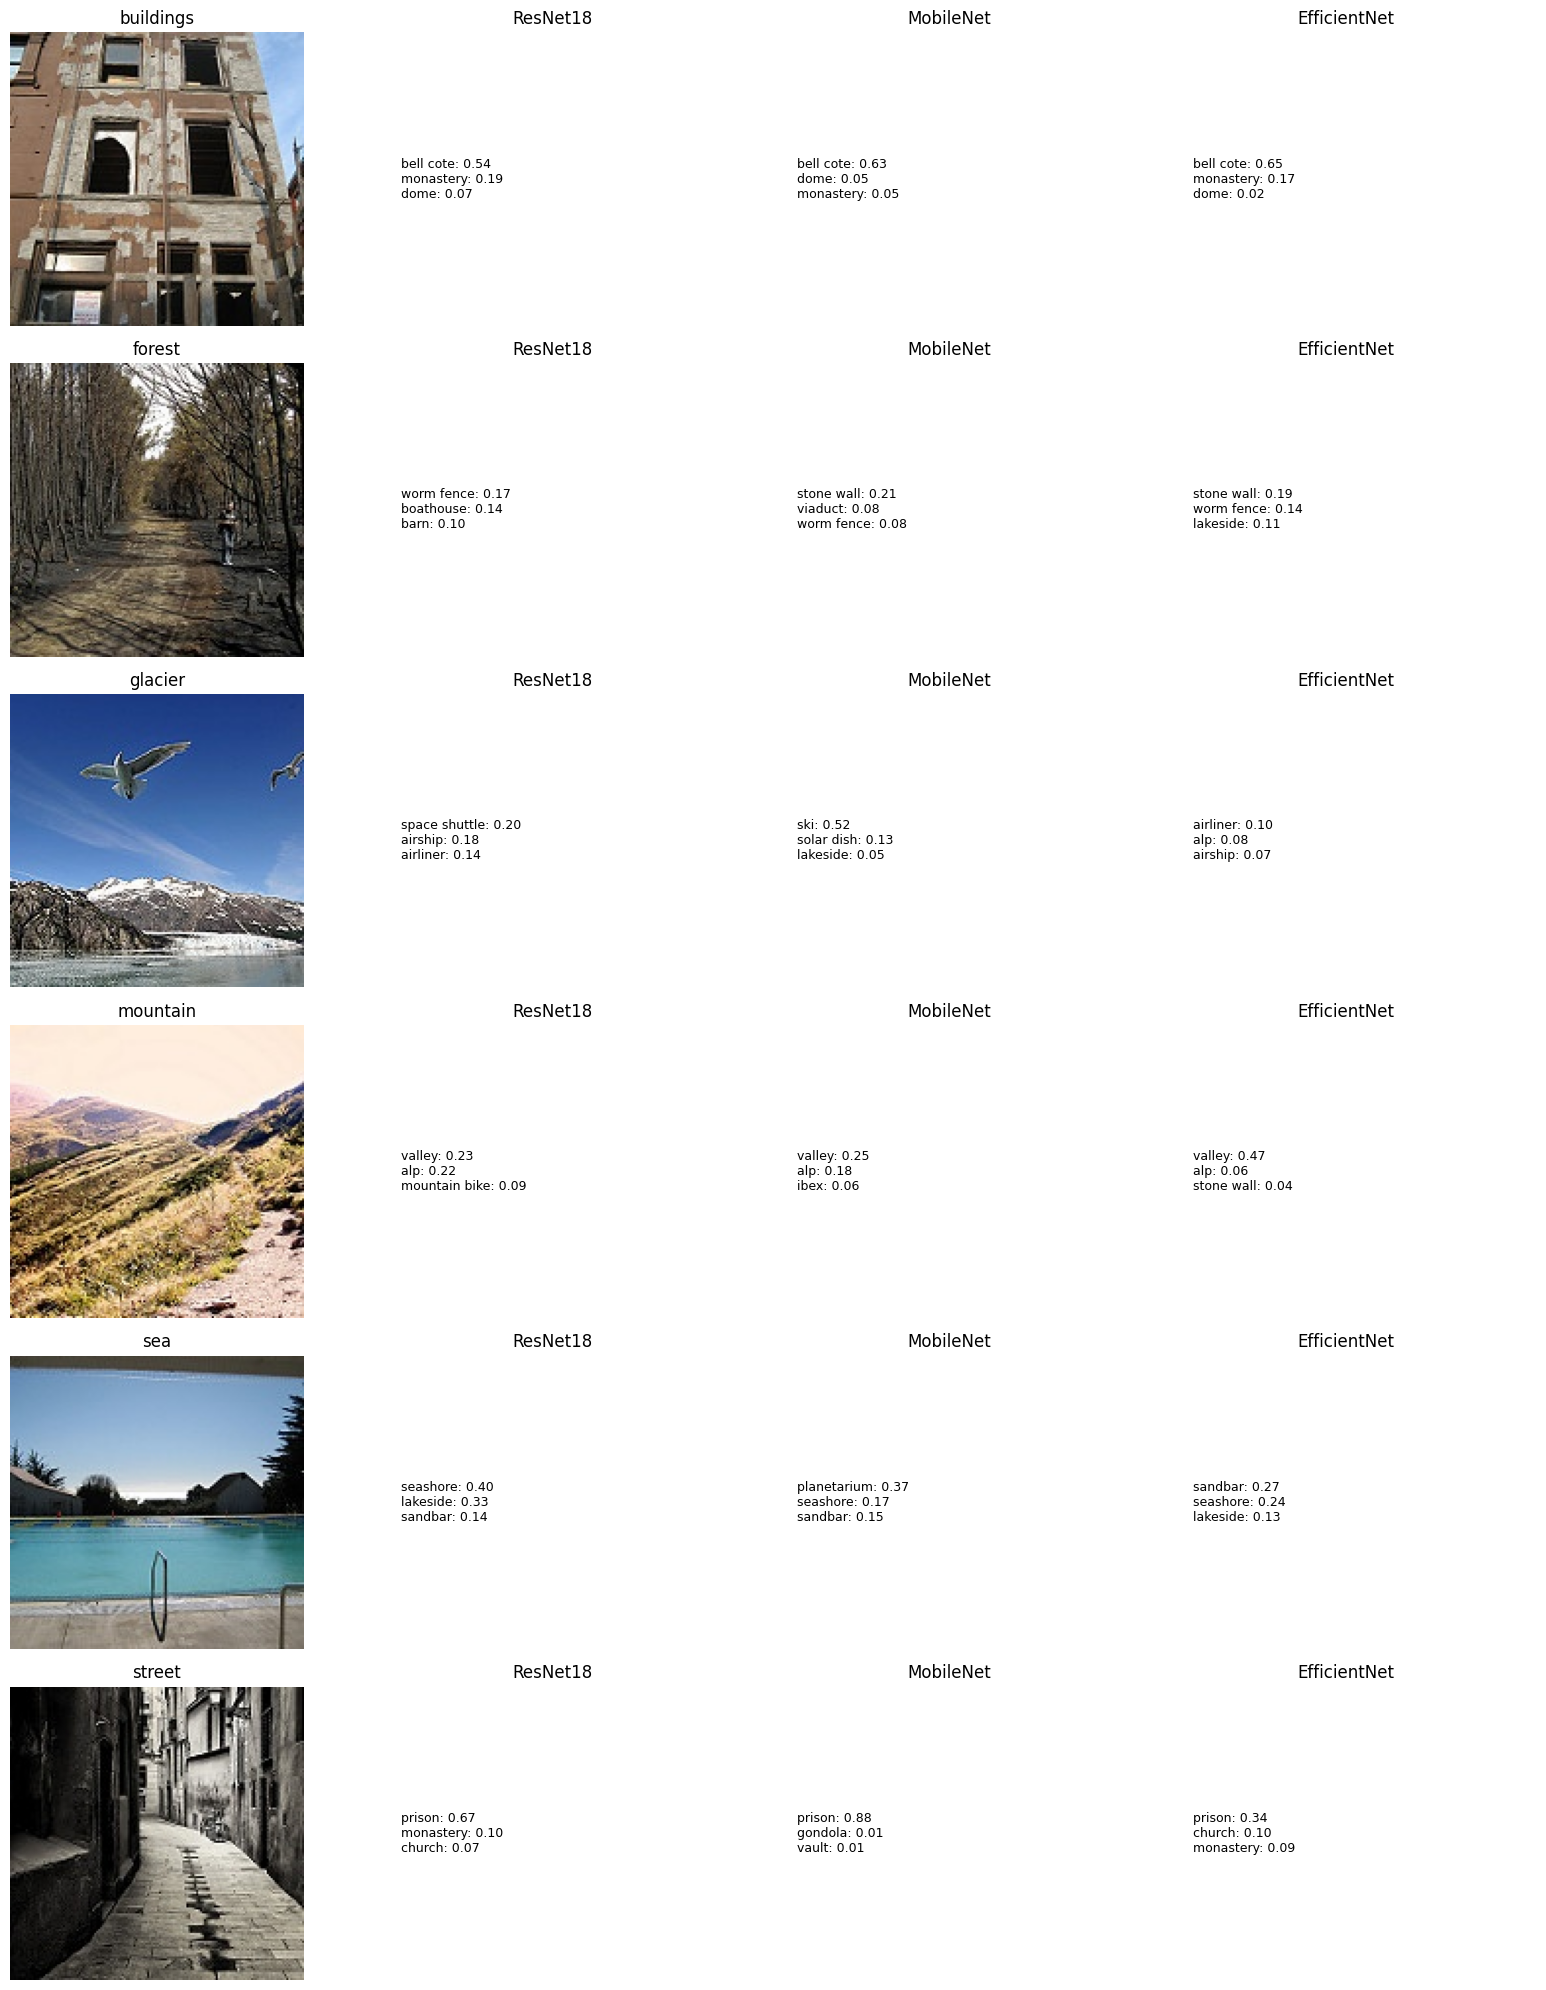

In [ ]:
fig, axes = plt.subplots(6, 4, figsize=(16, 20))

model_names = ["ResNet18", "MobileNet", "EfficientNet"]
results_lists = [resnet_results, mobilenet_results, effnet_results]

for row, label in enumerate(LABELS):
    # get one image from this class
    img = next(img for img, lbl in image_set if lbl == label)
    
    # column 0: show the image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(label)
    axes[row, 0].axis("off")
    
    # columns 1-3: one per model
    for col, (name, results) in enumerate(zip(model_names, results_lists), start=1):
        # find this label's result in the results list
        result = next(r for r in results if r["true_label"] == label)
        
        # grab top 3
        classes = result["top5_classes"][:3]
        probs = result["top5_probs"][:3]
        
        pred_text = "\n".join([f"{c}: {p:.2f}" for c, p in zip(classes, probs)])
        axes[row, col].text(0.1, 0.5, pred_text, fontsize=9, verticalalignment="center")
        axes[row, col].set_title(name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

"""
1. For the most part, all 3 models agree on their top prediction

2. They disagree on the sea image heavily. One says seashore, mobilenet says planetarium, 
efficientnet says sandbar. An ensemble would improve accuracy because all 3 models use different
approaches. Because their training is different, they can cover each others blind spots and smooth
out predictions. 

3 For mountain, they all listed valley. Looking at the image one can say it can also be 
considered a valley. Out of all 3, I would say Eddicient Net is more semantically sensible of the 3.
"""

### Task 4: Speed vs. Accuracy Tradeoff

In [11]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.04 ms/image
MobileNetV3-Small:  6.79 ms/image
EfficientNet-B0:    9.81 ms/image


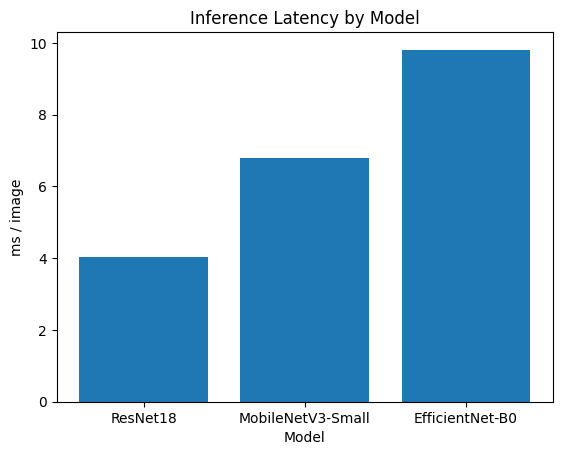

               Model  Parameters  ms / image
0           ResNet18    11689512    4.037340
1  MobileNetV3-Small     2542856    6.792601
2    EfficientNet-80     5288548    9.811676


In [ ]:
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.bar(model_names, latencies)
plt.title("Inference Latency by Model")
plt.xlabel("Model")
plt.ylabel("ms / image")
plt.savefig("outputs/inference_speed.png")
plt.show()

summary_table = pd.DataFrame({
    "Model": ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"],
    "Parameters": [
        sum(p.numel() for p in resnet.parameters()),
        sum(p.numel() for p in mobilenet.parameters()),
        sum(p.numel() for p in efficientnet.parameters())
    ],
    "ms / image": [resnet_ms, mobile_ms, effnet_ms]
})

print(summary_table)



Q1. 

Absolute maximum tolerable latency per image would be 20 milliseconds per image. 

Looking at my results, all 3 models meet the standard. The slowest model, EfficientNet-B0 is at ~10 milliseconds. Half the 20 milliseconds tolerance limit.

Q2. 

A. For a cloud pipeline, I would use ResNet18. It has the largest amount of Parameters with the lowest ms/image. 

B. For on-device mobile app, depends on the device. If we are talking nare minimum and optimized, MobileNet. It's made specifically for mobile. 

C. For Safety-Critical, I'm not sure. I think Efficient network would be better. It takes longer to process and it seems to have stronger confidence in decisions than the other 2 models. 

### Task 5: Pretrained Features as a Window into Transfer Learning

In [13]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


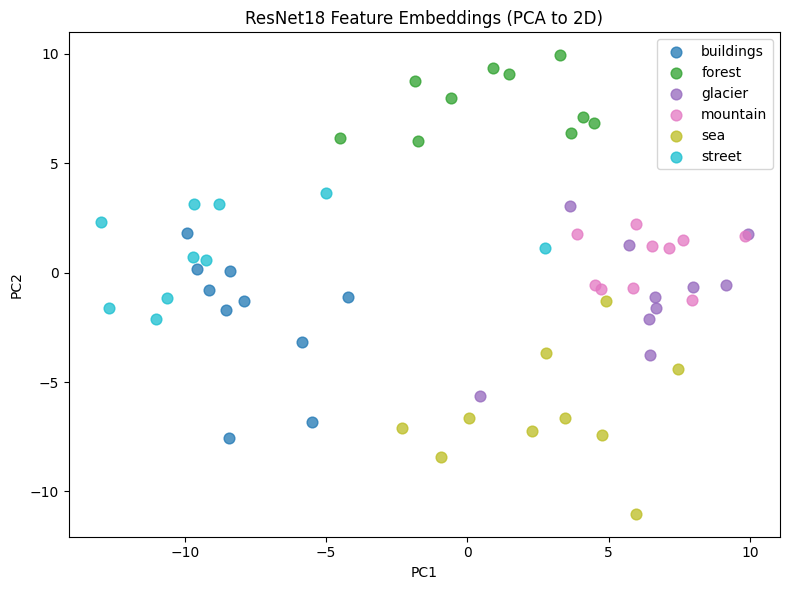

In [14]:
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

Q1. Images from the same class tend to cluster together. Some notable observations is street and buildings mix together often. Sea is something the models struggle with. Same with Forest. Further training on these images is required.

Q2. With only 500 labeled examples, feature extraction is better. Re-training the entire model requires more data and resources. If you are using a model but just need a new task, it is easier to train a new final layer and/or the next layer above. 

### Task 6: Summary and Recommendation

1. 

Based on my specific results, it is hard to say. If I had to pick one, I would say MobileNet was more accurate. It's confidence scores were also the highest when it was correct. It's latency was in the middle between Resnet and EfficientNet so I say it held its own for the most part. 
The reason I struggle to pick a winner is because in 4 of 6 images, they all shared similar findings. For Glacier, I can see how the bird may be thought of as a space shuttle or airliner. On Forest, MobileNet is the only one that had a higher confidence is stone wall. I can see how forest may look like a stone wall.

So with that said, MobileNet is the pick for me. Decent speed while still being somewhat accurate.


2. 
Confidence Calibration: Looking at the boxplot from Task 2, which scene types was ResNet18 most and least confident about? Does that match your intuition about which scenes are visually distinctive?

ResNet18 was most confident building and street. It was not confident about forest and glacier. I can see why it chose certain aspects. The bird's position can make it appear like a space shuttle. With the building and street, it definitely understood it was an image of an urban environment. With further refinement, it has potential.


3. 
I would choose the MobileNet model. The MobileNet model has similar confidence scores to the Resnet and EfficientNet model. However, its speed is faster than EfficientNet and it's confidence when it is right is higher than Resnet so I see it as the winner. 

Preprocessing steps:
1. Resize to the shorter side to 256 pixels to maintain aspect ratio
2. Crop the middle 224 X 224 which is the default input size requirement across different models
3. Normalize Ranges: Converting pixel integer values to floating point between [0,1] or [-1,1].


One critical risk to flag before shipping is issues caused by poor user quality images and night shots. The dataset the model is trained on consists of clean images. Model confidence will plummet with images that are unclear and/or little lighting.

